# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** Teresia Marito Sihombing
- **Email:** tereshmbng@gmail.com
- **ID Dicoding:** tereshmbng

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang memiliki volume penjualan tertinggi dan terendah di platform marketplace Olist berdasarkan jumlah item terjual selama periode Januari 2017 hingga Agustus 2018, dan bagaimana perbedaan kontribusi revenue antar kategori tersebut?
- **Pertanyaan 2:** Bagaimana pola pertumbuhan total revenue bulanan platform Olist selama periode tahun 2017, dan pada bulan apa revenue mencapai titik tertinggi serta faktor apa yang kemungkinan mendorongnya?
- **Pertanyaan 3:** Bagaimana perbandingan frekuensi transaksi dan rata-rata nilai belanja per order antara returning customer dan new customer di platform Olist selama periode September 2016 hingga Agustus 2018?

## Import Semua Packages/Library yang Digunakan

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df_order_items

In [62]:
# Tabel order items
df_order_items = pd.read_csv('/content/order_items_dataset.csv')
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Load df_product

In [63]:
# Tabel products
df_product = pd.read_csv('/content/products_dataset.csv')
df_product.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


#### Load df_order_payments

In [64]:
# Tabel order payments
df_order_payments = pd.read_csv('/content/order_payments_dataset.csv')
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### Load df_order

In [65]:
# Tabel order
df_order = pd.read_csv('/content/orders_dataset.csv')
df_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Load df_customer

In [66]:
# Tabel customers
df_customer = pd.read_csv('/content/customers_dataset.csv')
df_customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### Load df_kategori

In [67]:
# Tabel kategori translation
df_kategori = pd.read_csv('/content/product_category_name_translation.csv')
df_kategori.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Assessing Data

#### Identifying type data

In [68]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [69]:
df_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [70]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [71]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [72]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [73]:
df_kategori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Steps to Take:**
- Konversi type data pada df_order khusus kolom tanggal, karena masih bertipe object (bukan datetime).

**Insight:**
- df_order_items memiliki tipe data yang sudah sesuai.
- df_product memiliki tipe data yang sudah sesuai.
- df_order_payments memiliki tipe data yang sudah sesuai.
- df_order memiliki tipe data yang belum sesuai (date untuk tanggal).
- df_customer memiliki tipe data yang sudah sesuai.
- df_kategori memiliki tipe data yang sudah sesuai.

#### Identifying missing values

In [74]:
df_order_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [75]:
df_product.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [76]:
df_order_payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [77]:
df_order.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [78]:
df_customer.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [79]:
df_kategori.isna().sum()

,0
product_category_name,0
product_category_name_english,0


**Steps to Take:**
- Drop missing values pada tabel df_product.
- Tidak melakukan apa pun pada tabel df_order, karena yang akan digunakan untuk analisis adalah kolom order_status, bukan yang memiliki missing values.

**Insight:**
- df_order_items tidak memiliki missing values.
- df_product memiliki 610 missing values pada kolom product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, dan 2 missing values pada kolom product_weight_g, product_length_cm, product_height_cm, product_width_cm.
- df_order_payments tidak memiliki missing values.
- df_order memiliki 160 missing values pada kolom order_approved_at, 1783 missing values pada order_delivered_carrier_date, dan 2965 missing values pada order_delivered_customer_date. Semua kolom ini tidak berpengaruh pada step selanjutnya, sehingga tidak perlu dihapus karena missing valuesnya cukup banyak.
- df_customer tidak memiliki missing values.
- df_kategori tidak memiliki missing values.

#### Identifying duplicate data

In [80]:
print("Jumlah duplikasi: ",df_order_items.duplicated().sum())

Jumlah duplikasi:  0


In [81]:
print("Jumlah duplikasi: ",df_product.duplicated().sum())

Jumlah duplikasi:  0


In [82]:
print("Jumlah duplikasi: ",df_order_payments.duplicated().sum())

Jumlah duplikasi:  0


In [83]:
print("Jumlah duplikasi: ",df_order.duplicated().sum())

Jumlah duplikasi:  0


In [84]:
print("Jumlah duplikasi: ",df_customer.duplicated().sum())

Jumlah duplikasi:  0


In [85]:
print("Jumlah duplikasi: ",df_kategori.duplicated().sum())

Jumlah duplikasi:  0


**Steps to Take:**
- Melanjutkan pemeriksaan data.

#### Identifying data scale, anomaly, and range

In [86]:
df_order_items.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [87]:
df_product.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [88]:
df_order_payments.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [89]:
df_order.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [90]:
df_customer.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [91]:
df_kategori.describe(include="all")

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Steps to Take:**
- Pemeriksaan sudah selesai, bisa lanjut ke step berikutnya.

### Cleaning Data

#### Fixing missing values on df_product

In [92]:
# Drop baris yang tidak punya kategori (610 produk tidak lengkap)
df_product = df_product.dropna(subset=['product_category_name'])

# Isi missing values kolom dimensi dengan median
cols_dimensi = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in cols_dimensi:
    df_product[col] = df_product[col].fillna(df_product[col].median())

print("Missing values setelah cleaning:")
print(df_product.isna().sum())
print(f"\nSisa produk : {len(df_product):,}")

Missing values setelah cleaning:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Sisa produk : 32,341


**Insight:**
- Missing values pada product_category_name hanya sedikit, sehingga lebih efektif untuk di drop.
- Sedangkan untuk kolom dimensi barang, dilakukan imputasi dengan median (karena tidak sensitif terhadap outlier).
- Sisa data setelah dibersihkan adalah 32,341.

#### Fixing type data on df_order

In [93]:
# Konversi tipe data (dari object ke datetime)
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    df_order[col] = pd.to_datetime(df_order[col])

print("Tipe data setelah konversi:")
print(df_order[datetime_cols].dtypes)

Tipe data setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [94]:
# Filter hanya order yang sudah delivered yang akan diolah
orders_delivered = df_order[df_order['order_status'] == 'delivered'].copy()

print(f"Total semua order        : {len(df_order):,}")
print(f"Order status delivered   : {len(orders_delivered):,}")
print(f"Order non-delivered      : {len(df_order) - len(orders_delivered):,}")

Total semua order        : 99,441
Order status delivered   : 96,478
Order non-delivered      : 2,963


In [95]:
# Rentang tanggal
print(f"Tanggal pertama : {df_order['order_purchase_timestamp'].min()}")
print(f"Tanggal terakhir: {df_order['order_purchase_timestamp'].max()}")

# Menghitung jumlah order per tahun
df_order['year'] = df_order['order_purchase_timestamp'].dt.year
print(f"\nJumlah order per tahun:")
print(df_order['year'].value_counts().sort_index())

# Menghitung jumlah di tahun 2016
orders_2016 = df_order[df_order['year'] == 2016]
print(f"\nDetail bulan di 2016:")
print(orders_2016['order_purchase_timestamp'].dt.month.value_counts().sort_index())

Tanggal pertama : 2016-09-04 21:15:19
Tanggal terakhir: 2018-10-17 17:30:18

Jumlah order per tahun:
year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

Detail bulan di 2016:
order_purchase_timestamp
9       4
10    324
12      1
Name: count, dtype: int64


In [96]:
# Filter hanya order yang sudah delivered yang akan diolah (ambil dari orders_delivered)
orders_clean = orders_delivered.copy()

print(f"Total order          : {len(df_order):,}")
print(f"Order setelah filter : {len(orders_clean):,}")

Total order          : 99,441
Order setelah filter : 96,478


**Insight:**
- Pada tahun 2016, tidak tercatat penjualan bulan November. Lalu, 2016 platform baru berjalan, sehingga penjualan yang tercatat masih sangat sedikit.
- Kita akan menganalisis tahun 2017 saja.
- Tidak perlu menangani missing values pada kolom yang ada missing values, karena yang dipakai hanya kolom order_status yang tidak ada missing valuesnya.
- Kita hanya memakai data produk dengan status delivered, karena ingin mengevaluasi hasil penjualan yang benar-benar diterima oleh pembeli. Jadi, produk yang dikembalikan atau belum diterima tidak dianalisis.

## Exploratory Data Analysis (EDA)

### Explore Kategori Produk dengan Penjualan Terlaris dan Terburuk

In [97]:
# Merge items dengan products untuk mendapatkan kolom kategori
df = df_order_items.merge(
    df_product[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print(f"Shape sebelum merge : {df_order_items.shape}")
print(f"Shape setelah merge : {df.shape}")
print(f"Missing category    : {df['product_category_name'].isna().sum()}")

Shape sebelum merge : (112650, 7)
Shape setelah merge : (112650, 8)
Missing category    : 1603


In [98]:
# Merge df (hasil merge sebelumnya) dengan kategori untuk mendapatkan kolom translation english
df = df.merge(
    df_kategori,
    on='product_category_name',
    how='left'
)

print(f"Jumlah baris =", len(df))
df.head()

Jumlah baris = 112650


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [99]:
# Filter orders_delivered ke Jan 2017 - Agustus 2018
orders_delivered_q1 = orders_delivered[
    (orders_delivered['order_purchase_timestamp'] >= '2017-01-01') &
    (orders_delivered['order_purchase_timestamp'] < '2018-09-01')
].copy()

# Merge dengan orders_delivered_q1
df = df.merge(
    orders_delivered_q1,
    on='order_id',
    how='inner'
)

print(f"Jumlah baris = {len(df)}")
df.head()

Jumlah baris = 109880


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17


In [100]:
# Membuat tabel pivot berdasarkan product_category_name_english
pivot_kategori = df.groupby('product_category_name_english').agg(
    total_items_sold = ('order_item_id', 'count'),
    total_revenue    = ('price', 'sum'),
    avg_price        = ('price', 'mean'),
).round(2).sort_values('total_items_sold', ascending=False)

display(pivot_kategori)

,total_items_sold,total_revenue,avg_price
product_category_name_english,,,
bed_bath_table,10945,1022955.77,93.46
health_beauty,9422,1229557.50,130.50
sports_leisure,8414,952840.40,113.24
furniture_decor,8095,706237.17,87.24
computers_accessories,7632,888055.59,116.36
...,...,...,...
arts_and_craftmanship,24,1814.01,75.58
la_cuisine,14,2054.99,146.78
cds_dvds_musicals,14,730.00,52.14


In [101]:
top5  = pivot_kategori.head(5)
bot5  = pivot_kategori.tail(5)

print("=== TOP 5 KATEGORI PRODUK PENJUALAN TERLARIS ===")
display(top5)

print("=== BOTTOM 5 KATEGORI PRODUK PENJUALAN TERENDAH ===")
display(bot5)

=== TOP 5 KATEGORI PRODUK PENJUALAN TERLARIS ===


,total_items_sold,total_revenue,avg_price
product_category_name_english,,,
bed_bath_table,10945,1022955.77,93.46
health_beauty,9422,1229557.50,130.50
sports_leisure,8414,952840.40,113.24
furniture_decor,8095,706237.17,87.24
computers_accessories,7632,888055.59,116.36


=== BOTTOM 5 KATEGORI PRODUK PENJUALAN TERENDAH ===


,total_items_sold,total_revenue,avg_price
product_category_name_english,,,
arts_and_craftmanship,24,1814.01,75.58
la_cuisine,14,2054.99,146.78
cds_dvds_musicals,14,730.00,52.14
fashion_childrens_clothes,7,519.95,74.28
security_and_services,2,283.29,141.64


**Insight:**
- bed_bath_table adalah kategori terlaris dengan 10.945 item terjual, namun revenue-nya (1,022,955 kalah dari health_beauty (1,229,557) yang terjual lebih sedikit. Hal ini dikarenakan avg price health_beauty (130) lebih tinggi dibanding bed_bath_table (93).
- security_and_services adalah kategori paling sedikit terjual dengan hanya 2 item, namun avg price-nya lebih tinggi dari bed_bath_table. Ini menunjukkan kategori ini bukan tidak bernilai, melainkan niche premium dengan permintaan sangat terbatas.
- Dari top 5, computers_accessories punya avg price cukup tinggi (116) dengan volume besar (7,632 item). Kombinasi ini menghasilkan revenue 888.055, menjadikannya kategori yang efisien secara bisnis.

### Explore Tren Revenue

In [102]:
# Memeriksa berapa banyak order yang punya lebih dari 1 baris payment
payment_per_order = df_order_payments.groupby('order_id')['payment_sequential'].count()

print(f"Total order unik di payments     : {payment_per_order.shape[0]:,}")
print(f"Order dengan 1 payment           : {(payment_per_order == 1).sum():,}")
print(f"Order dengan >1 payment          : {(payment_per_order > 1).sum():,}")

Total order unik di payments     : 99,440
Order dengan 1 payment           : 96,479
Order dengan >1 payment          : 2,961


In [103]:
# Menggabungkan order yang punya lebih dari 1 baris payment (supaya tidak muncul berulang)
payment_agg = df_order_payments.groupby('order_id').agg(
    total_payment = ('payment_value', 'sum')
).reset_index()

print(f"Total order di payments : {len(payment_agg):,}")
print(f"\nSample:")
payment_agg.head()

Total order di payments : 99,440

Sample:


,order_id,total_payment
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [104]:
# Menggabungkan tabel order (delivered) dengan payment_agg
df_revenue = orders_clean.merge(
    payment_agg,
    on='order_id',
    how='left'
)

# Filter hanya tahun 2017
df_revenue = df_revenue[
    (df_revenue['order_purchase_timestamp'] >= '2017-01-01') &
    (df_revenue['order_purchase_timestamp'] < '2018-01-01')
].copy()

print(f"Jumlah baris setelah filter : {len(df_revenue):,}")
df_revenue.head()

Jumlah baris setelah filter : 43,428


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_payment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,175.26
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,75.16
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,35.95


In [105]:
# Mengubah time stamp detail menjadi per bulan (supaya menghemat baris)
df_revenue['year_month'] = df_revenue['order_purchase_timestamp'].dt.to_period('M')

print("Sample kolom year_month:")
print(df_revenue[['order_purchase_timestamp', 'year_month']].head())
print(f"\nRentang period: {df_revenue['year_month'].min()} s/d {df_revenue['year_month'].max()}")

Sample kolom year_month:
  order_purchase_timestamp year_month
0      2017-10-02 10:56:33    2017-10
3      2017-11-18 19:28:06    2017-11
5      2017-07-09 21:57:05    2017-07
6      2017-05-16 13:10:30    2017-05
7      2017-01-23 18:29:09    2017-01

Rentang period: 2017-01 s/d 2017-12


In [106]:
# Pivot table revenue bulanan
pivot_revenue = df_revenue.groupby('year_month').agg(
    total_revenue  = ('total_payment', 'sum'),
    order_count    = ('order_id', 'count'),
    avg_order_value = ('total_payment', 'mean')
).round(2)

display(pivot_revenue)

,total_revenue,order_count,avg_order_value
year_month,,,
2017-01,127545.67,750,170.06
2017-02,271298.65,1653,164.13
2017-03,414369.39,2546,162.75
2017-04,390952.18,2303,169.76
2017-05,567066.73,3546,159.92
2017-06,490225.60,3135,156.37
2017-07,566403.93,3872,146.28
2017-08,646000.61,4193,154.07
2017-09,701169.99,4150,168.96


**Insight:**
- November 2017 adalah bulan terbaik dengan revenue 1,153,528 dan order count tertinggi 7,289, hampir 2x lipat bulan sebelumnya (Oktober 2017: 4,478 order).
- avg_order_value justru cenderung turun seiring waktu, dari 170 di Januari 2017 perlahan turun ke 152 di Desember 2017. Artinya pertumbuhan revenue lebih didorong oleh jumlah order yang naik, bukan karena pelanggan belanja lebih mahal per transaksi.

### Explore Customer

In [107]:
print(f"Total baris customers           : {len(df_customer):,}")
print(f"Unique customer_id              : {df_customer['customer_id'].nunique():,}")
print(f"Unique customer_unique_id       : {df_customer['customer_unique_id'].nunique():,}")
print(f"\nSelisih                       : {df_customer['customer_id'].nunique() - df_customer['customer_unique_id'].nunique():,}")

Total baris customers           : 99,441
Unique customer_id              : 99,441
Unique customer_unique_id       : 96,096

Selisih                       : 3,345


**Insight:**
- customer_id dan customer_unique_id berbeda.
- customer_id bersifat per transaksi, sedangkan customer_unique_id adalah identitas unik per orang.
- Artinya: ada customer yang melakukan transaksi lebih dari 1.

In [108]:
# Menggabungkan tabel order (delivered) dengan customer
customers = orders_delivered.merge(
    df_customer[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
).merge(
    payment_agg,
    on='order_id',
    how='left'
)

customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,total_payment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [109]:
# Menghitung jumlah pelanggan new vs berulang
frekuensi['segment'] = frekuensi['jumlah_order'].apply(
    lambda x: 'returning' if x > 1 else 'new'
)

print(f"\nJumlah new customer       : {(frekuensi['segment'] == 'new').sum():,}")
print(f"Jumlah returning customer : {(frekuensi['segment'] == 'returning').sum():,}")


Jumlah new customer       : 90,557
Jumlah returning customer : 2,801


**Insight:**
- Jumlah pelanggan yang melakukan hanya 1 kali transaksi adalah 90,557 orang. Ini disebut **new customer**.
- Jumlah pelanggan yang melakukan lebih dari 1 kali transaksi (atau pembelian berulang) adalah 2,801 orang. Ini disebut **returning customer**.

In [110]:
pivot_customer = frekuensi.groupby('segment').agg(
    jumlah_customer = ('customer_unique_id', 'count'),
    avg_frekuensi   = ('jumlah_order', 'mean'),
    avg_spending_per_order = ('avg_spending', 'mean'),
).round(2)

pivot_customer['pct_customer'] = (
    pivot_customer['jumlah_customer'] / pivot_customer['jumlah_customer'].sum() * 100
).round(2)

display(pivot_customer)

,jumlah_customer,avg_frekuensi,avg_spending_per_order,pct_customer
segment,,,,
new,90557,1.00,160.76,97.0
returning,2801,2.11,145.87,3.0


**Insight:**
- Rata-rata spending new customer lebih besar daripada returning customer, meskipun frekuensi belanjanya lebih besar returning customer.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memiliki volume penjualan tertinggi dan terendah di platform marketplace Olist berdasarkan jumlah item terjual selama periode Januari 2017 hingga Agustus 2018, dan bagaimana perbedaan kontribusi revenue antar kategori tersebut?

/tmp/ipykernel_5388/2631826157.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5388/2631826157.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


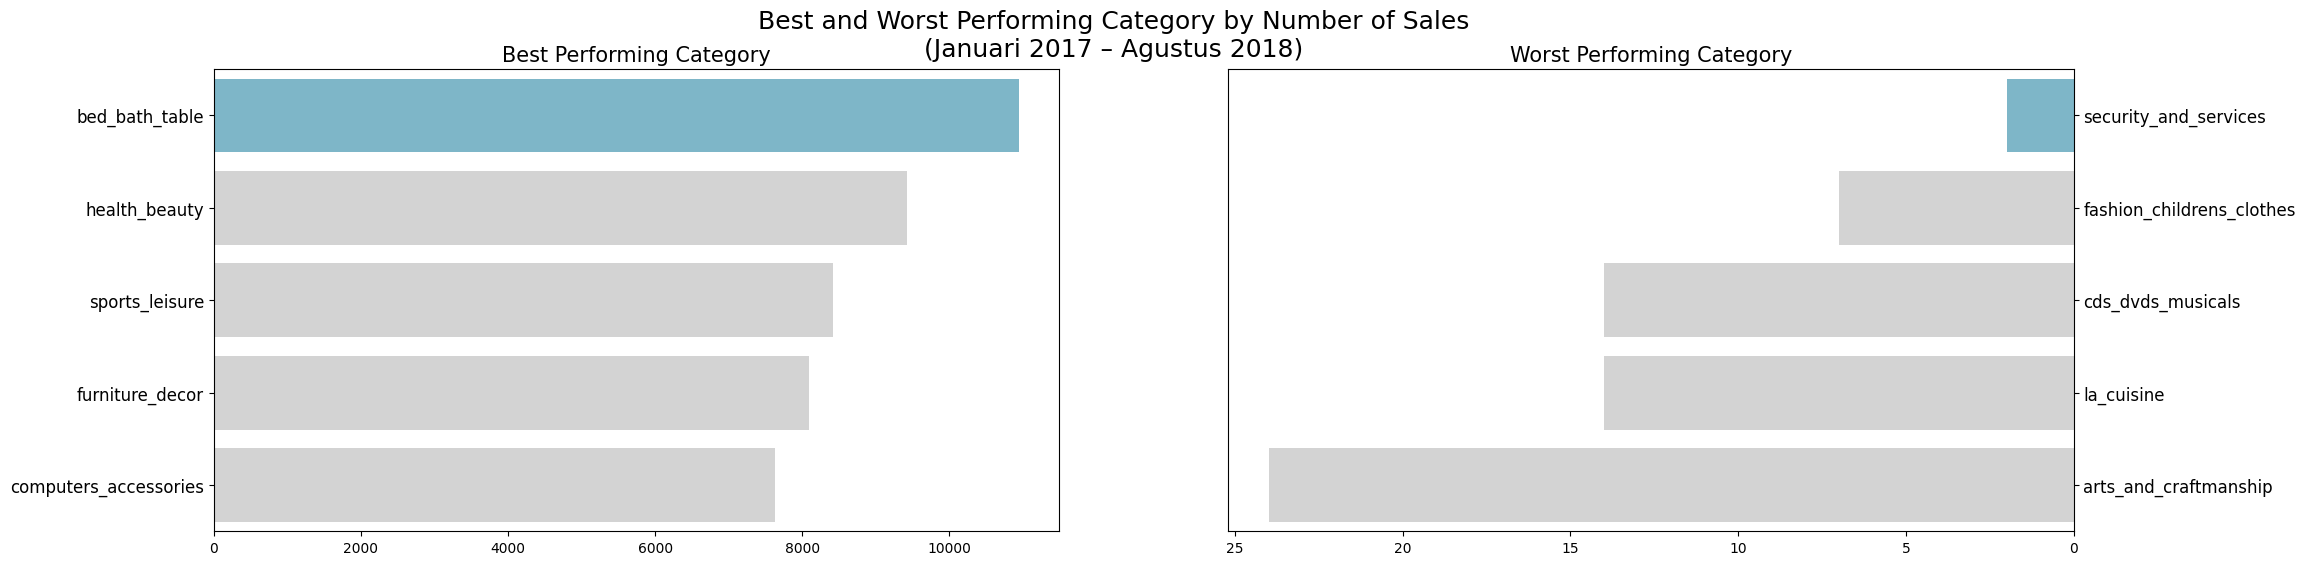

In [111]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Top 5
sns.barplot(
    x='total_items_sold',
    y=pivot_kategori.head(5).index,
    data=pivot_kategori.head(5).reset_index(),
    palette=colors,
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Category", loc="center", fontsize=15)
ax[0].tick_params(axis='y', labelsize=12)

# Bottom 5
bot5 = pivot_kategori.tail(5).sort_values('total_items_sold', ascending=True)
sns.barplot(
    x='total_items_sold',
    y=bot5.index,
    data=bot5.reset_index(),
    palette=colors,
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Category", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Performing Category by Number of Sales\n(Januari 2017 – Agustus 2018)", fontsize=18)
plt.show()

**Insight:**
- bed_bath_table adalah kategori terlaris dengan lebih dari 10,000 item terjual, diikuti health_beauty dan sports_leisure. Hal ini mencerminkan dominasi produk kebutuhan rumah tangga dan gaya hidup di Olist.
- security_and_services adalah kategori paling sedikit terjual dengan hanya 2 item, diikuti fashion_childrens_clothes dan cds_dvds_musicals. Hal ini kemungkinan disebabkan minimnya pilihan produk atau rendahnya permintaan pasar.
- Penjualan tinggi tidak selalu berarti revenue tertinggi. health_beauty menghasilkan revenue lebih besar dari bed_bath_table meski terjual lebih sedikit, karena rata-rata harga per itemnya lebih tinggi.

### Pertanyaan 2: Bagaimana pola pertumbuhan total revenue bulanan platform Olist selama periode tahun 2017, dan pada bulan apa revenue mencapai titik tertinggi serta faktor apa yang kemungkinan mendorongnya?

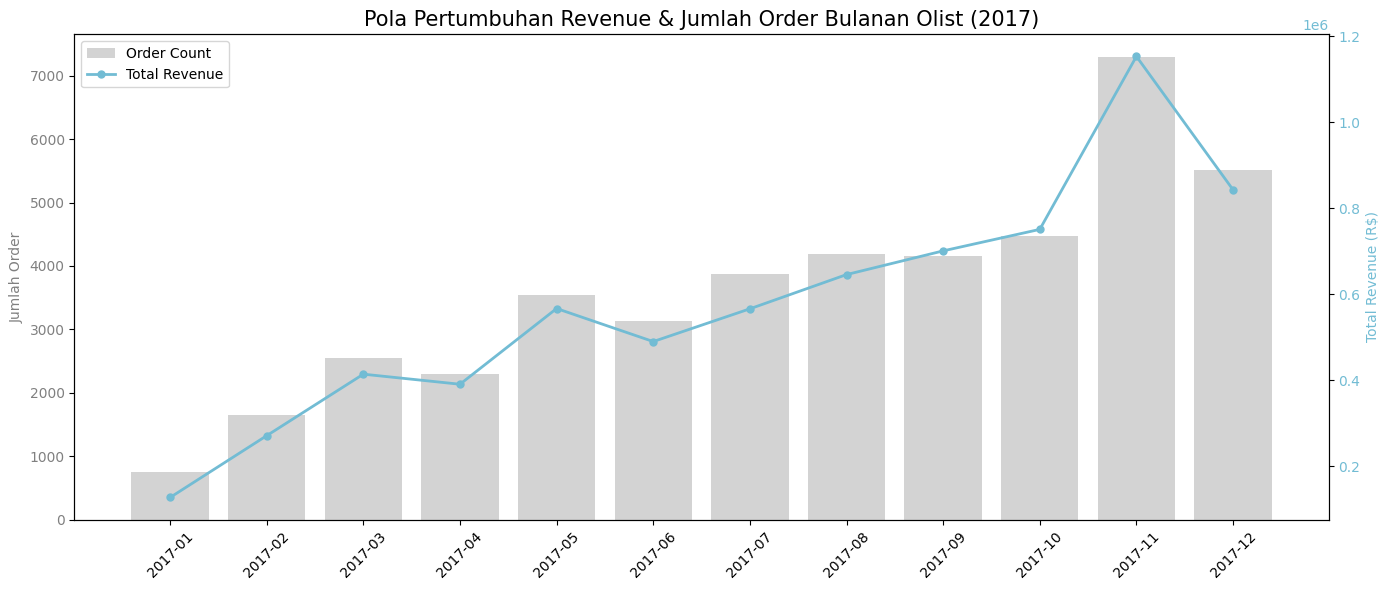

In [112]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart order count (sumbu kiri)
ax1.bar(
    pivot_revenue.index.astype(str),
    pivot_revenue['order_count'],
    color='#D3D3D3',
    label='Order Count'
)
ax1.set_ylabel('Jumlah Order', color='gray')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', labelcolor='gray')

# Line chart revenue (sumbu kanan)
ax2 = ax1.twinx()
ax2.plot(
    pivot_revenue.index.astype(str),
    pivot_revenue['total_revenue'],
    marker='o',
    color='#72BCD4',
    linewidth=2,
    markersize=5,
    label='Total Revenue'
)
ax2.set_ylabel('Total Revenue (R$)', color='#72BCD4')
ax2.tick_params(axis='y', labelcolor='#72BCD4')

# Legend gabungan
lines, labels = ax2.get_legend_handles_labels()
bars, blabels = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, blabels + labels, loc='upper left')

ax1.set_xlabel(None)
plt.title('Pola Pertumbuhan Revenue & Jumlah Order Bulanan Olist (2017)', fontsize=15)
plt.tight_layout()
plt.show()

In [113]:
# Filter df ke bulan November 2017
nov_2017 = df[
    (df['order_purchase_timestamp'].dt.year == 2017) &
    (df['order_purchase_timestamp'].dt.month == 11)
]

# Pivot per kategori
pivot_nov = nov_2017.groupby('product_category_name_english').agg(
    total_items_sold=('order_item_id', 'count')
).sort_values('total_items_sold', ascending=False)

print("=== TOP 10 KATEGORI TERLARIS NOVEMBER 2017 ===")
display(pivot_nov.head(10))

=== TOP 10 KATEGORI TERLARIS NOVEMBER 2017 ===


,total_items_sold
product_category_name_english,
bed_bath_table,961
furniture_decor,767
sports_leisure,597
health_beauty,573
garden_tools,547
computers_accessories,512
toys,485
watches_gifts,463
housewares,412


**Insight:**
- Revenue tumbuh signifikan dan konsisten sepanjang 2017, dari hampir nol di awal 2017 hingga menembus 1,1 juta di November 2017.
- November 2017 adalah puncak tertinggi dengan revenue mencapai 1,15 juta, kemungkinan besar didorong oleh momen Black Friday yang jatuh di bulan November, yang merupakan salah satu periode belanja terbesar di Brazil.
- Produk yang paling banyak di-order sebagian besar untuk kepentingan persiapan Natal (karena pada dasarnya Black Friday adalah hari belanja diskon besar-besaran tahunan yang jatuh pada hari Jumat keempat November di Amerika Serikat, menandai awal musim belanja Natal). Salah satu buktinya adalah produk kedua terbanyak yaitu furniture_decor.

### Pertanyaan 3: Bagaimana perbandingan frekuensi transaksi dan rata-rata nilai belanja per order antara returning customer dan new customer di platform Olist selama periode September 2016 hingga Agustus 2018?

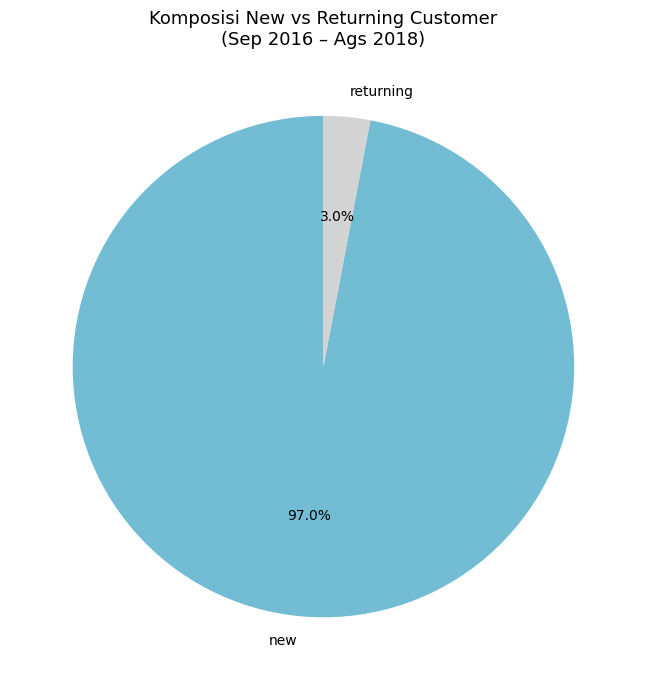

In [114]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    pivot_customer['jumlah_customer'],
    labels=pivot_customer.index,
    autopct='%1.1f%%',
    colors=['#72BCD4', '#D3D3D3'],
    startangle=90
)

ax.set_title('Komposisi New vs Returning Customer\n(Sep 2016 – Ags 2018)', fontsize=13)
plt.tight_layout()
plt.show()

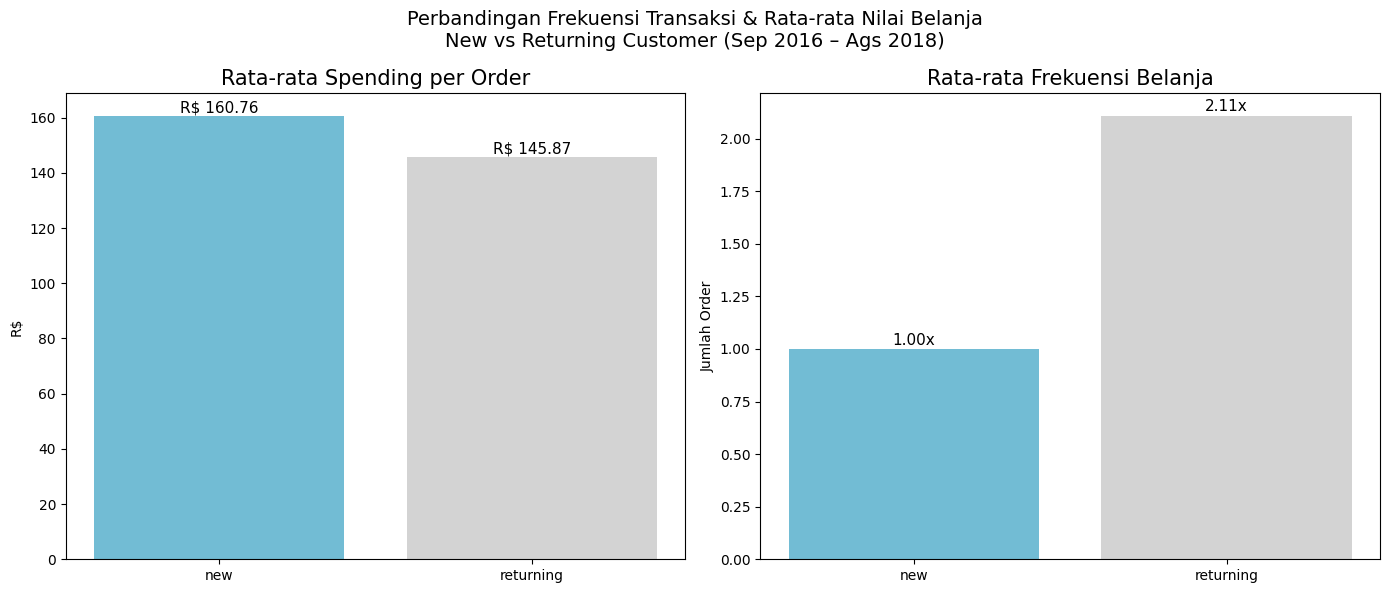

In [115]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Kiri — avg spending per order
ax[0].bar(
    pivot_customer.index,
    pivot_customer['avg_spending_per_order'],
    color=['#72BCD4', '#D3D3D3']
)
ax[0].set_title('Rata-rata Spending per Order', fontsize=15)
ax[0].set_ylabel('R$')
for i, v in enumerate(pivot_customer['avg_spending_per_order']):
    ax[0].text(i, v + 1, f'R$ {v:,.2f}', ha='center', fontsize=11)

# Kanan — avg frekuensi
ax[1].bar(
    pivot_customer.index,
    pivot_customer['avg_frekuensi'],
    color=['#72BCD4', '#D3D3D3']
)
ax[1].set_title('Rata-rata Frekuensi Belanja', fontsize=15)
ax[1].set_ylabel('Jumlah Order')
for i, v in enumerate(pivot_customer['avg_frekuensi']):
    ax[1].text(i, v + 0.02, f'{v:.2f}x', ha='center', fontsize=11)

plt.suptitle('Perbandingan Frekuensi Transaksi & Rata-rata Nilai Belanja\nNew vs Returning Customer (Sep 2016 – Ags 2018)', fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**
- Dari sisi frekuensi, returning customer belanja lebih sering (rata-rata 2.11x) dibanding new customer (1x).
- Dari sisi spending per order, justru new customer yang lebih besar (160.76) dibanding returning customer (145.87). Artinya customer yang baru pertama kali belanja cenderung membeli barang yang lebih mahal per transaksinya.
- New customer mungkin membeli barang "besar" di awal (elektronik, furnitur, barang mahal) lalu tidak kembali lagi karena sudah terpenuhi kebutuhannya.
- Returning customer cenderung belanja barang kebutuhan rutin yang lebih murah (produk kecantikan, makanan) sehingga nilai per ordernya lebih kecil tapi frekuensinya lebih tinggi.

## Conclusion

**Pertanyaan 1:** Kategori produk apa yang memiliki volume penjualan tertinggi dan terendah di platform marketplace Olist berdasarkan jumlah item terjual selama periode Januari 2017 hingga Agustus 2018, dan bagaimana perbedaan kontribusi revenue antar kategori tersebut?

Kategori **bed_bath_table** mendominasi penjualan dengan 10.953 item terjual, diikuti health_beauty dan sports_leisure. Namun menariknya, bed_bath_table bukanlah kategori yang menghasilkan revenue tertinggi, melainkan **health_beauty** karena avg price per item-nya lebih tinggi (130 vs 93). Di sisi lain, **security_and_services** menjadi kategori paling sedikit terjual dengan hanya 2 item.

**Rekomendasi:** Fokuskan anggaran promosi dan pemasaran pada kategori **health_beauty** dan **bed_bath_table** karena keduanya terbukti paling diminati dan menghasilkan revenue terbesar. Untuk kategori dengan volume rendah seperti security_and_services dan fashion_childrens_clothes, Olist perlu mengevaluasi apakah perlu menambah pilihan produk dari seller atau justru mengurangi alokasi slot kategori tersebut di platform.

**Pertanyaan 2:** Bagaimana pola pertumbuhan total revenue bulanan platform Olist selama periode tahun 2017, dan pada bulan apa revenue mencapai titik tertinggi serta faktor apa yang kemungkinan mendorongnya?

Revenue Olist menunjukkan pertumbuhan yang sangat pesat sepanjang 2017, dari 127 ribu di Januari 2017 hingga mencapai puncaknya di 1,15 juta pada November 2017. Pertumbuhan ini terutama didorong oleh kenaikan jumlah order, bukan kenaikan nilai per transaksi. Hal ini dikarenakan avg_order_value justru cenderung turun dari 170 menjadi sekitar 152 seiring waktu. Puncak November kemungkinan besar didorong oleh momentum Black Friday.

**Rekomendasi:** Olist perlu menyiapkan kampanye promosi lebih awal di bulan Oktober untuk memaksimalkan momentum Black Friday di November. Selain itu, karena pertumbuhan revenue lebih didorong volume order bukan nilai per transaksi, Olist perlu strategi untuk meningkatkan avg order value. Misalnya: fitur bundle produk, minimum pembelian untuk gratis ongkir, atau rekomendasi produk cross-selling.

**Pertanyaan 3:** Bagaimana perbandingan frekuensi transaksi dan rata-rata nilai belanja per order antara returning customer dan new customer di platform Olist selama periode September 2016 hingga Agustus 2018?

Returning customer memang belanja lebih sering (rata-rata 2,11x) dibanding new customer yang hanya 1x. Namun yang mengejutkan, new customer justru spending lebih besar per transaksi (160,76 vs 145,87), mengindikasikan bahwa pelanggan baru cenderung membeli barang bernilai tinggi di pembelian pertama, sementara returning customer berbelanja lebih rutin dengan nilai yang lebih kecil. Dari total 93.358 customer, hanya 2.801 (3%) yang merupakan returning customer, menunjukkan tantangan untuk mempertahankan loyalitas pelanggan yang sangat besar.

**Rekomendasi:** Karena 97% customer hanya belanja sekali, Olist perlu program yang bisa mempertahankan loyalitas pelanggan seperti voucher pembelian kedua, loyalty points, atau personalized recommendation untuk mendorong new customer kembali berbelanja. Untuk returning customer yang spending-nya lebih kecil, Olist bisa membuat program subscription atau bundling produk kebutuhan rutin seperti health_beauty dan food_drink agar frekuensi transaksi tetap terjaga dengan nilai yang lebih optimal.